In [40]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import ceil
# from scipy.stats import uniform
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit

from re_forecast.data.get_data import get_rte_data
from re_forecast.preprocessing.preprocess_data import preprocess_data
from re_forecast.exploration.plot import plot_time_serie
from re_forecast.preprocessing.make_supervised import transform_dt_df_into_supervised

# Training with random forest (and AdaBoost)

Objectives of this notebook :
- Base steps :  
  - Import data
  - Impute missing values
  - Create a dataset suited for supervised learning
- Train-test split :  
  - Find a way to train-test split without shuffling
- Baseline :  
  - Compute a baseline score
- Random forest
  - Test to fit a random forest model
  - Perform a grid (or random) search cross-validation to find out the best set of parameters for the random forest model
  - Create a rolling forcast function of the best model and compare the results to the test set
- AdaBoost
  - Grid or random search cv
  - Rolling forecast, plot and evaluate on the test set

## Params

Global parameters for this notebook, change the behavior of the the learning process here.

In [27]:
#######################################
# Global parameters for this notebook #
#######################################

# Name of the value column
VALUE_COL = "value"

# The number of supervised features determine how much we lag the value column from
# the original time serie df to create new features, and by the same create the supervised df corresponding.
NB_SUPERVISED_FEATURES = 24

# Scoring to use in the grid search
SCORING = "neg_mean_absolute_error"

## Base steps

- Import data
- Impute missing values

In [28]:
# Set the parameters
ressource_nb = 2
start_date = "2022-06-01 00:00:00" # Note: don't modify the start & end date for following requests
end_date = "2024-03-01 00:00:00"
eic_code = "17W0000014455708"
production_type = None
production_subtype = None

# Download generation data: don't forget to set the api_delay_bypass to true in the params in this case,
# and to reset it to false if you know that you will download fresh data from the api
gen_data = get_rte_data(ressource_nb = ressource_nb,
                        start_date = start_date,
                        end_date = end_date,
                        eic_code = eic_code,
                        production_type = production_type,
                        production_subtype = production_subtype)

# Preprocess the data with the preprocess pipeline: check data quality,
# construct a time-consistent df, constrain min and max values and impute missing values
gen_data_dt_preprocessed = preprocess_data(gen_data)

# Plot
plot_time_serie(gen_data_dt_preprocessed,
                "",
                "value",
                dt_index = True)

- Create a dataset suited for supervised learning

In [29]:
# Transform the time serie df into a df suited for supervised learning
gen_data_dt_supervised = transform_dt_df_into_supervised(gen_data_dt_preprocessed,
                                                         value_col = "value",
                                                         nb_features = NB_SUPERVISED_FEATURES)

# Drop the rows containing Nans
gen_data_dt_supervised.dropna(axis = 0, inplace = True)

## Train-test split

- Train-test split without shuffling

In [30]:
# Define X and y from the supervised df
X, y = gen_data_dt_supervised.drop(columns = [VALUE_COL]), gen_data_dt_supervised[[VALUE_COL]]

# Train test split with the train_test_split sklearn function
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.7, shuffle = False)

## Compute a baseline score

In [31]:
# Construct a serie of the same lenght than the test set
# and of constant value equal to the last value of the training set.
base_model_predictions = np.repeat(y_train.iloc[-1, :].value, len(y_test))

# Compute the baseline MAE
BASE_MAE = mean_absolute_error(y_test[VALUE_COL], base_model_predictions)
print(f"{BASE_MAE:.2f}")

102.12


## Random forest

First test of a fit of a random forest model

In [32]:
# Instanciate the model
test_rf_model = RandomForestRegressor(random_state = 42)

# Fit
test_rf_model.fit(X_test, y_test)

/home/bender/.pyenv/versions/3.10.6/envs/re_forecast_env/lib/python3.10/site-packages/sklearn/base.py:1152: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



RandomForestRegressor(random_state=42)

Perform a grid (or random) search cross-validation to find out the best set of parameters for the random forest model.  
Note : We have to perform a time serie split (without shuffling) to cross validate our data using the TimeSeriesSplit object from sklearn.  
More here :  
- https://towardsdatascience.com/how-to-cross-validation-with-time-series-data-9802a06272c6
- https://medium.com/@mouse3mic3/a-practical-guide-on-scikit-learn-for-time-series-forecasting-bbd15b611a5d

The list of parameters we want to test is the following :  
- n_estimators : The maximum number of trees the random forest model will create
- max_depth : The maximum number of stage for a tree. This is an interesting parameter, because the purity of leaves depend on it, and control the params min_samples_leaf and min_weight_fraction_leaf.
- max_features : The maximum number of features to consider for a split when building a tree. Note that for each split, the random forest algorithm choose randomly max_features features amoung the total set of features.

In [8]:
# Instanciate the model
rf_model = RandomForestRegressor(random_state = 42)

# Define the grid  with the choosen params
grid = {
        "n_estimators": [i for i in range(1, 301)],
        #"max_depth": [i for i in range(1, 4)],
        #"max_features": [i for i in range(1, NB_SUPERVISED_FEATURES + 1)]
        }

# Define the time serie split
tss = TimeSeriesSplit(n_splits = 5)

# Random or grid search with time series split
# Note: for the time serie split, we perform a time
# serie split with refit and increasing train set size
search = GridSearchCV(rf_model,
                      param_grid = grid,
                      # n_iter = 2000,
                      scoring = SCORING,
                      cv = tss,
                      # random_state = 42,
                      n_jobs = -1)

# Fit
search.fit(X_train, y_train)

# Results
results = search.cv_results_

# Summarize results
print(f"The mean absolute error of the best model is : {-search.best_score_:.2f}")
print(f"The bests hyperparameters are :")
for param, value in search.best_params_.items():
    print(f"- {param} : {value}")

/home/bender/.pyenv/versions/3.10.6/envs/re_forecast_env/lib/python3.10/site-packages/sklearn/base.py:1152: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/bender/.pyenv/versions/3.10.6/envs/re_forecast_env/lib/python3.10/site-packages/sklearn/base.py:1152: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/bender/.pyenv/versions/3.10.6/envs/re_forecast_env/lib/python3.10/site-packages/sklearn/base.py:1152: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/bender/.pyenv/versions/3.10.6/envs/re_forecast_env/lib/python

The mean absolute error of the best model is : 11.51
The bests hyperparameters are :
- n_estimators : 16


The random forest regressor only allow to forecast one step at a time. To forecast for a given period of time, we have to forecast within 'for' loops and perform a rolling forecast.

In [33]:
# Define the function that perform a rolling forecast for a sklearn model in a given time window
def rolling_forecast_in_window(X_train: pd.DataFrame,
                               fitted_model: object,
                               window_size: int,
                               ) -> list:
    """Perform a rolling forecast using a fitted scikit-learn model
    inside a given time window. At each time step, the previous predicted
    data point is used as a new feature for the next prediction.
    Arguments:
    - X_train: the training features to give to the model
    - fitted_model: a fitted scikit-learn model
    - window_size: the size of the time window"""

    # Forecasts list: iteratively store the forecasts in this list
    forecasts_list = []

    # Take the bottom row of X_train as initial forecast data
    forecast_data = X_train.iloc[-1, :].values.reshape((1, -1))

    # Iterate the window size + 1, because we drop the first value at the end
    # (we already have the real value)
    for _ in range(window_size + 1):
        # Predict
        forecast = fitted_model.predict(forecast_data)

        # Store the forecast in the forecasts_list
        forecasts_list.append(forecast[0])

        # Construct the forecast data
        stack_tuple = forecast_data[:, 1:], forecast.reshape((1, 1))
        forecast_data = np.hstack(stack_tuple)

    # Drop the first value of the forecast list (we already have the real value)
    return forecasts_list[1:]


# Define the rolling forecast with random forest regressor function
def rolling_sklearn_model(gen_df: pd.DataFrame,
                          value_col: str,
                          nb_features: int,
                          forecast_window: int,
                          sklearn_model: object,
                          initial_train_split: float = 0.7,
                          **sklearn_model_params
                          ) -> pd.Series:
    """Perform a rolling forecast for time series using a scikit-learn machine
    learning model. The rolling model predict values for a given time window.
    The values predicted are used as features to compute forecast data point
    inside a window. After predicting a window, a new model is fitted using
    real data points. The window forecasts are aggregated inside a pandas serie.
    Arguments:
    - gen_df: the time serie data we use to train and forecast
    - value_col: the column which contain the time serie values
    - nb_features: the number of features to consider when transforming the gen_df into a supervised df
    - forecast_window: the size of the time window
    - sklearn_model: the scikit-learn model object
    - **sklearn_model_params: the parameters of the scikit-learn model
    Parameter:
    - initial_train_split: the train split proportion by default"""

    ######################################
    # 1/ Initial steps: Prepare the data #
    ######################################

    # Store the forecasts inside lists
    forecasts = []

    # Transform the time serie df into a df suited for supervised learning
    gen_data_dt_supervised = transform_dt_df_into_supervised(gen_df,
                                                             value_col = value_col,
                                                             nb_features = nb_features)

    # Drop the rows containing Nans
    gen_data_dt_supervised.dropna(axis = 0, inplace = True)

    # Define X and y from the supervised df
    X, y = gen_data_dt_supervised.drop(columns = [value_col]), gen_data_dt_supervised[[value_col]]

    # Train test split with the train_test_split sklearn function
    X_train, _, y_train, y_test = train_test_split(X, y,
                                                   train_size = initial_train_split,
                                                   shuffle = False)

    # Store the initial y_test index to reuse for the results
    forecast_index = y_test.index

    #####################################################
    # 2/ Set up the parameters for the rolling forecast #
    #####################################################

    # Initial lenght of the train set
    len_initial_train_set = len(y_train)

    # Compute the number of forecast windows to forecast
    nb_forecast_windows = ceil(len(y_test) / forecast_window)

    # Compute the residual number of time steps
    resid = len(y_test) % forecast_window

    ###################################
    # 3/ Perform the rolling forecast #
    ###################################

    # Iterate over the number of forecast windows
    for k in range(1, nb_forecast_windows + 1):

        # Fit a sklearn model with its given params
        model = sklearn_model(**sklearn_model_params)
        fitted_model = model.fit(X_train, y_train)

        # Compute the size of the window dynamically depending on the window number k
        window_size = forecast_window if k < nb_forecast_windows else resid

        # Update the forecast list using the rolling forecast function
        forecasts = forecasts + rolling_forecast_in_window(X_train,
                                                           fitted_model,
                                                           window_size)

        # Update X_train and y_train: add data from X_test and y_test
        # corresponding to the window size
        train_split = len_initial_train_set + k * forecast_window
        train_split = min(train_split, len(gen_data_dt_supervised))

        # If else condition to avoid the problem of having the train
        # split equal to len of X, which sklearn train_test_split doesn't accept
        if k < nb_forecast_windows:
            X_train, _, y_train, _ = train_test_split(X, y,
                                                      train_size = train_split,
                                                      shuffle = False)

        else:
            X_train, y_train = X, y

    # Return the forecast as pandas serie
    return pd.Series(data = forecasts,
                     index = forecast_index,
                     name = value_col)


In [34]:
# Define a plot forecasts function
def plot_rolling_forecasts(train_set: pd.DataFrame | pd.Series,
                           test_set: pd.DataFrame | pd.Series,
                           rolling_forecast_results: pd.DataFrame | pd.Series,
                           performance_metric: object,
                           figsize: tuple = (16, 9)
                           ) -> None:
    """Plot the result of a rolling forecast alongside the
    train set and test set.
    Arguments:
    - train_set: the train set (time serie, 1 column)
    - test_set: the test set (time serie, 1 column)
    - rolling_forecast_results: the results of the rolling forecast (1 column)
    - forecast_window: the size of the forecast time span given in number of rows
    - performance_metric: the performance metric function (scikit-learn functions)
    Parameters:
    - figsize: size of the matplotlib fig"""

    # Compute the score of the metric
    performance_score = performance_metric(test_set, rolling_forecast_results)
    forecast_message = f"Forecast : {performance_metric.__name__} = {performance_score:.2f}"

    # Plot
    plt.figure(figsize = figsize)
    plt.plot(train_set, label = 'Train set', color = 'navy')
    plt.plot(test_set, label = 'Test set', color = 'navy', ls = '--')
    plt.plot(rolling_forecast_results, label = forecast_message, color = 'orange')
    plt.title('Forecast vs Actuals')
    plt.legend(loc = 'upper left', fontsize = 10)

/home/bender/.pyenv/versions/3.10.6/envs/re_forecast_env/lib/python3.10/site-packages/sklearn/base.py:1152: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().

/home/bender/.pyenv/versions/3.10.6/envs/re_forecast_env/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning:

X does not have valid feature names, but RandomForestRegressor was fitted with feature names

/home/bender/.pyenv/versions/3.10.6/envs/re_forecast_env/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning:

X does not have valid feature names, but RandomForestRegressor was fitted with feature names

/home/bender/.pyenv/versions/3.10.6/envs/re_forecast_env/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning:

X does not have valid feature names, but RandomForestRegressor was fitted with feature names

/home/bender/.pyenv/versions/3.10.6/envs/re_forecast_env/lib/python3.10/site-packages/skle

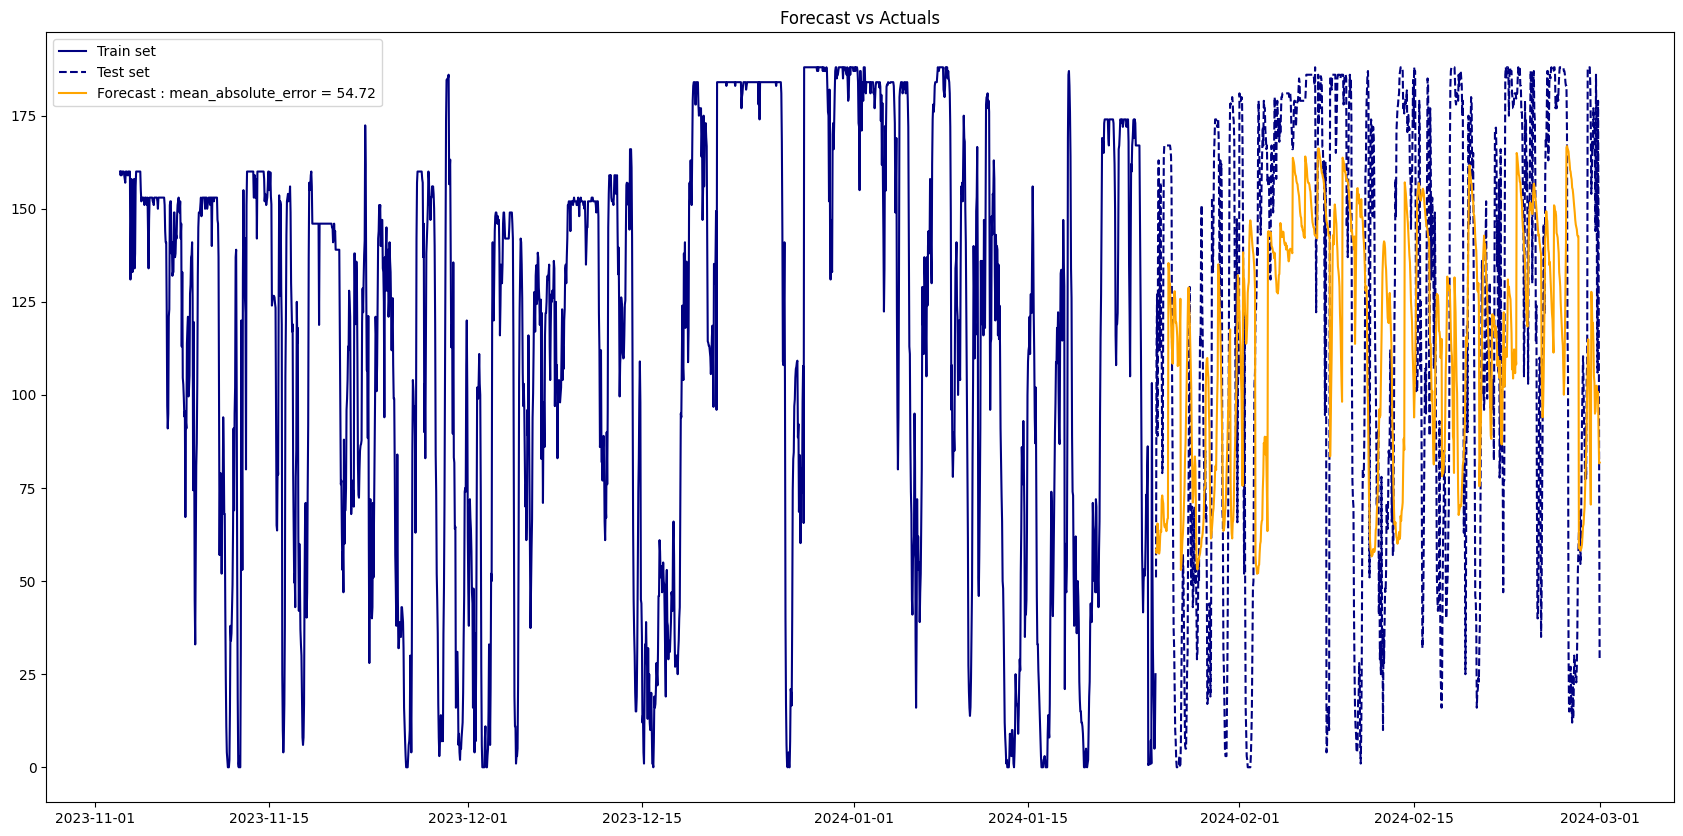

In [48]:
# Test the rolling forecast function
forecasts_rf_model = rolling_sklearn_model(gen_data_dt_preprocessed,
                                           "value",
                                           NB_SUPERVISED_FEATURES,
                                           24,
                                           RandomForestRegressor,
                                           random_state = 42,
                                           max_depth = 2,
                                           max_features = 2,
                                           n_estimators = 150)

# Plot the results
plot_rolling_forecasts(y_train,
                       y_test,
                       forecasts_rf_model,
                       mean_absolute_error,
                       figsize = (21, 10))

## AdaBoost

Grid (or random) search cv :

The parameters of interest for AdaBoost are :  
- n_estimators

We initialize the base estimator as a regression tree with a max depth of 1.

In [20]:
# Instanciate the model
ab_model = AdaBoostRegressor(base_estimator = DecisionTreeRegressor(max_depth = 1),
                             loss = "exponential",
                             random_state = 42)

# Define the grid  with the choosen params
grid = {
        "n_estimators": [i for i in range(1, 301)],
        #"max_depth": [i for i in range(1, 4)],
        #"max_features": [i for i in range(1, NB_SUPERVISED_FEATURES + 1)]
        }

# Define the time serie split
tss = TimeSeriesSplit(n_splits = 5)

# Random or grid search with time series split
# Note: for the time serie split, we perform a time
# serie split with refit and increasing train set size
search = GridSearchCV(ab_model,
                      param_grid = grid,
                      # n_iter = 2000,
                      scoring = SCORING,
                      cv = tss,
                      # random_state = 42,
                      n_jobs = -1)

# Fit
search.fit(X_train, y_train)

# Results
results = search.cv_results_

# Summarize results
print(f"The mean absolute error of the best model is : {-search.best_score_:.2f}")
print(f"The bests hyperparameters are :")
for param, value in search.best_params_.items():
    print(f"- {param} : {value}")

/home/bender/.pyenv/versions/3.10.6/envs/re_forecast_env/lib/python3.10/site-packages/sklearn/utils/validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/bender/.pyenv/versions/3.10.6/envs/re_forecast_env/lib/python3.10/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/home/bender/.pyenv/versions/3.10.6/envs/re_forecast_env/lib/python3.10/site-packages/sklearn/utils/validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/bender/.pyenv/versions/3.10.6/envs/re_forecast_env/lib/python3.10/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimato

The mean absolute error of the best model is : 24.42
The bests hyperparameters are :
- n_estimators : 12


/home/bender/.pyenv/versions/3.10.6/envs/re_forecast_env/lib/python3.10/site-packages/sklearn/utils/validation.py:1183: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/home/bender/.pyenv/versions/3.10.6/envs/re_forecast_env/lib/python3.10/site-packages/sklearn/ensemble/_base.py:156: FutureWarning:

`base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.



Rolling forecast, plot and evaluate on the test set with the bests parameters :

/home/bender/.pyenv/versions/3.10.6/envs/re_forecast_env/lib/python3.10/site-packages/sklearn/utils/validation.py:1183: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/home/bender/.pyenv/versions/3.10.6/envs/re_forecast_env/lib/python3.10/site-packages/sklearn/ensemble/_base.py:156: FutureWarning:

`base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.

/home/bender/.pyenv/versions/3.10.6/envs/re_forecast_env/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning:

X does not have valid feature names, but AdaBoostRegressor was fitted with feature names

/home/bender/.pyenv/versions/3.10.6/envs/re_forecast_env/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning:

X does not have valid feature names, but AdaBoostRegressor was fitted with feature names

/home/bender/.pyenv/versions/3.10.6/envs/re_forecast_env/lib/python3.10/site-pa

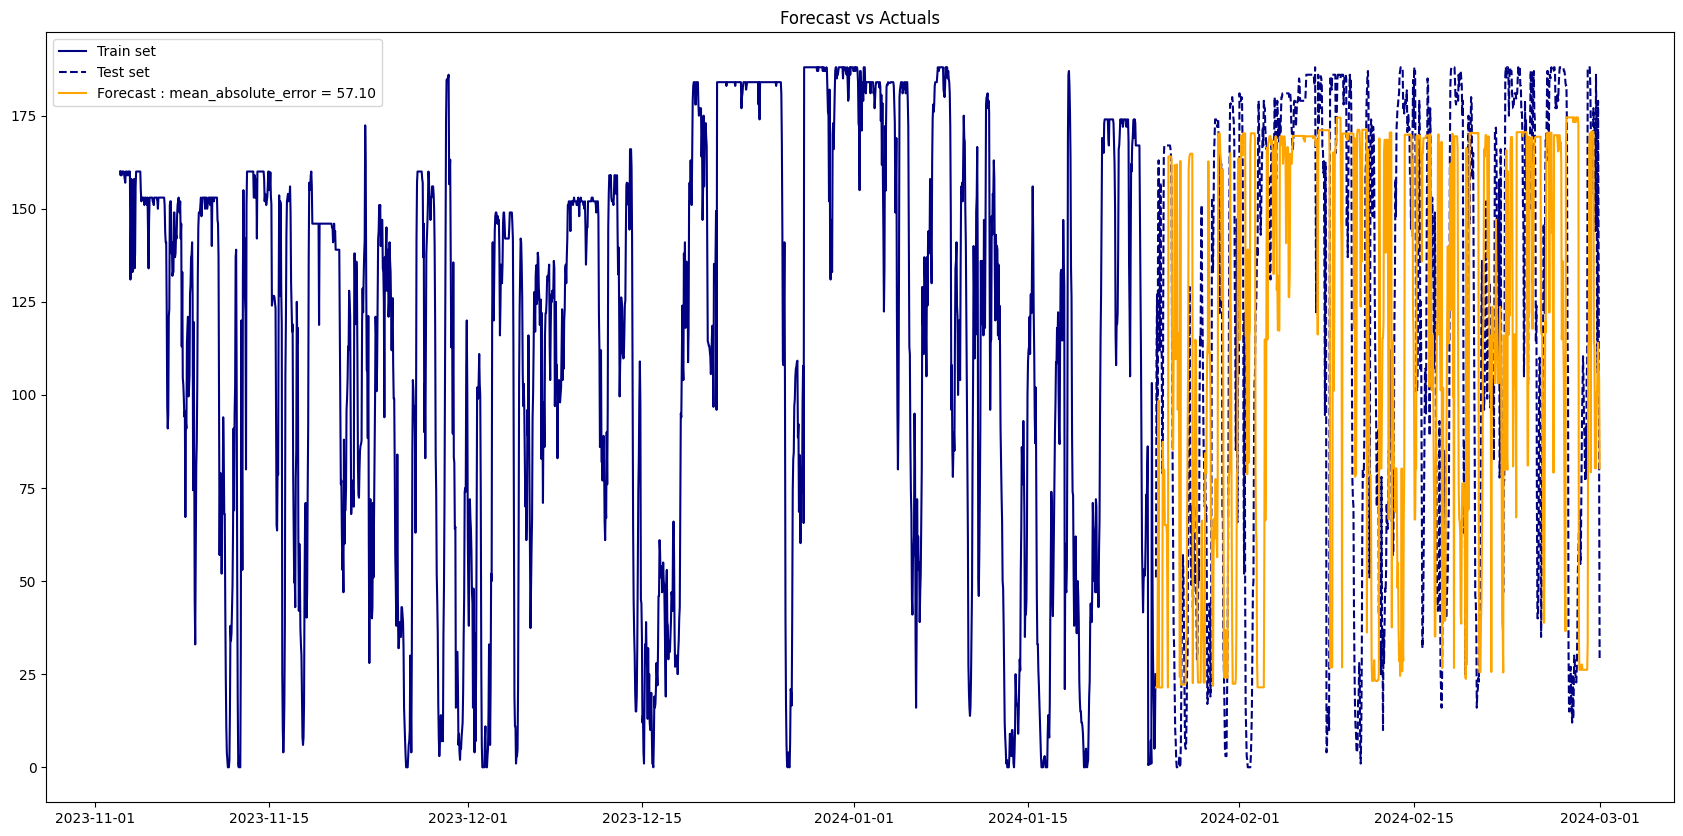

In [57]:
# Test the rolling forecast function
forecasts_ab_model = rolling_sklearn_model(gen_data_dt_preprocessed,
                                           "value",
                                           NB_SUPERVISED_FEATURES,
                                           24,
                                           AdaBoostRegressor,
                                           base_estimator = DecisionTreeRegressor(max_depth = 2),
                                           n_estimators = 50,
                                           learning_rate = 0.1,
                                           loss = "exponential",
                                           random_state = 42)

# Plot the results
plot_rolling_forecasts(y_train,
                       y_test,
                       forecasts_ab_model,
                       mean_absolute_error,
                       figsize = (21, 10))

## Bonus : Regression using KNN

Let's try to forecast using a KNN, find a good number of neighbors by hand and compute the mean absolute error against the test set.

/home/bender/.pyenv/versions/3.10.6/envs/re_forecast_env/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning:

X does not have valid feature names, but KNeighborsRegressor was fitted with feature names

/home/bender/.pyenv/versions/3.10.6/envs/re_forecast_env/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning:

X does not have valid feature names, but KNeighborsRegressor was fitted with feature names

/home/bender/.pyenv/versions/3.10.6/envs/re_forecast_env/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning:

X does not have valid feature names, but KNeighborsRegressor was fitted with feature names

/home/bender/.pyenv/versions/3.10.6/envs/re_forecast_env/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning:

X does not have valid feature names, but KNeighborsRegressor was fitted with feature names

/home/bender/.pyenv/versions/3.10.6/envs/re_forecast_env/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning:

X does not have valid featu

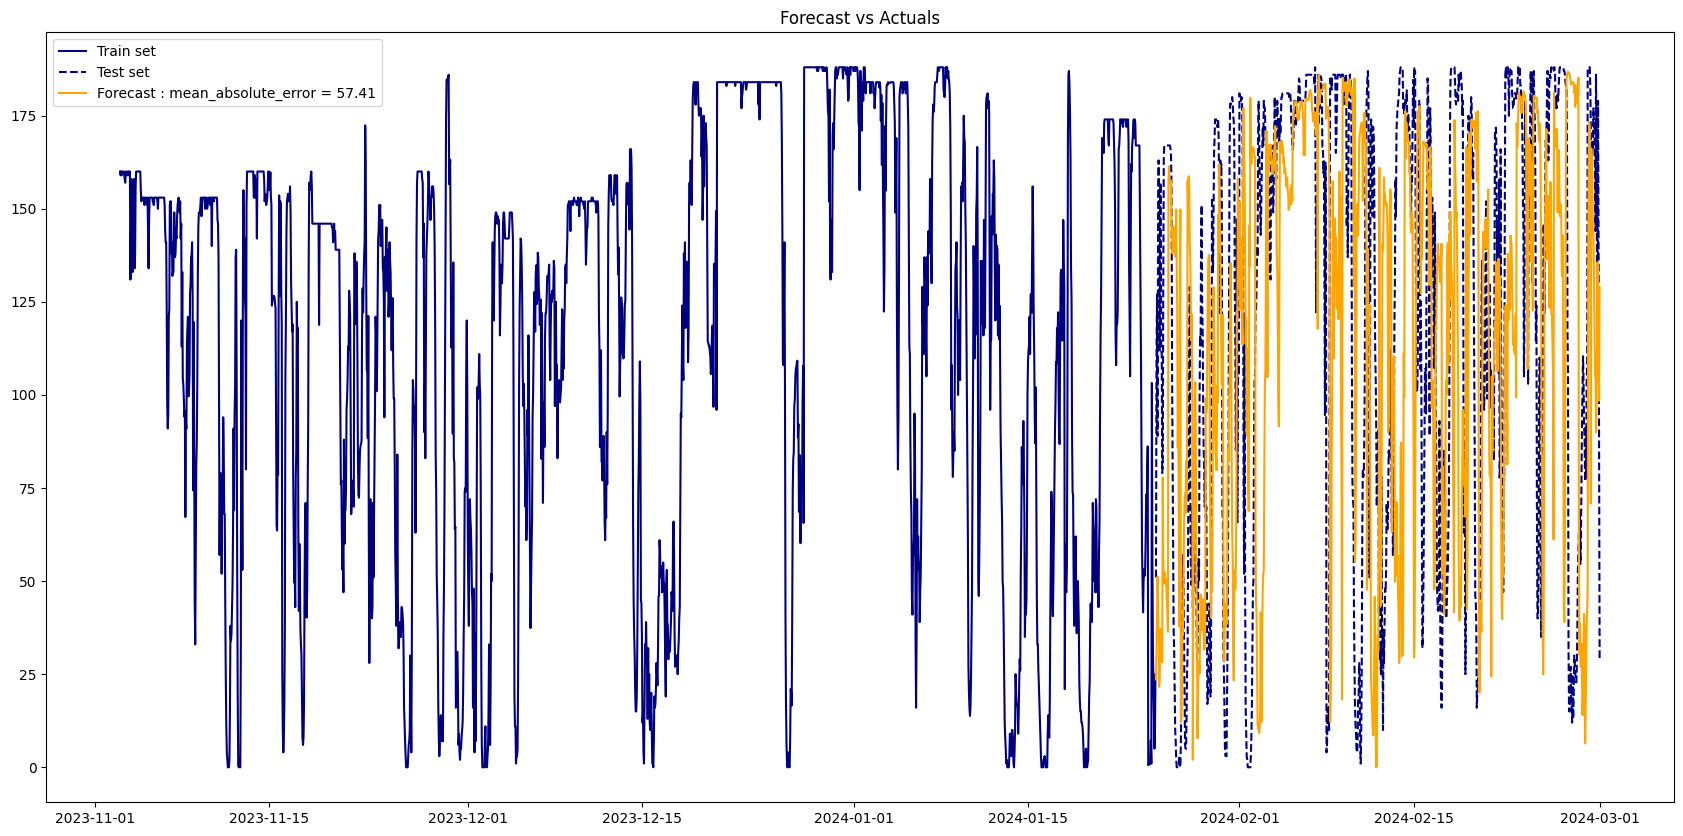

In [59]:
# Test the rolling forecast function
forecasts_ab_model = rolling_sklearn_model(gen_data_dt_preprocessed,
                                           "value",
                                           NB_SUPERVISED_FEATURES,
                                           24,
                                           KNeighborsRegressor,
                                           n_neighbors = 5)

# Plot the results
plot_rolling_forecasts(y_train,
                       y_test,
                       forecasts_ab_model,
                       mean_absolute_error,
                       figsize = (21, 10))